## Project Name - DeepCSAT: Customer Satisfaction Prediction for E-Commerce

### Project Type - Classification + EDA

Contribution - Individual

**BY - Kumari Vrishti**


## **Project Summary**

Customer satisfaction is one of the most critical success metrics for modern e-commerce platforms. In highly competitive digital marketplaces, retaining customers depends largely on the quality of customer support services. Poor customer experiences lead to negative reviews, reduced repeat purchases, and potential revenue loss. Therefore, predicting and improving customer satisfaction levels has become an important strategic objective for online businesses.

This project focuses on predicting Customer Satisfaction Score (CSAT) using machine learning techniques applied to customer support interaction data. The dataset contains approximately 85,000 customer service interactions collected from an e-commerce platform. Each record represents a customer support ticket and includes variables such as communication channel, product category, issue type, customer city, order time, response time, agent handling time, and agent details.

The main objective of this project is to analyze the data, discover patterns that influence customer satisfaction, and build a machine learning model capable of predicting CSAT scores based on operational and interaction variables. By doing so, the organization can identify the factors that most strongly impact customer experience and improve service quality.

The project begins with Exploratory Data Analysis (EDA) to understand the dataset structure, distribution of variables, and relationships between features and customer satisfaction scores. Visualization techniques such as histograms, bar charts, box plots, heatmaps, and pair plots are used to explore patterns and uncover insights. This stage helps identify key drivers of satisfaction such as response time, product category, and customer interaction channel.

After the exploratory phase, the dataset undergoes data preprocessing, which includes handling missing values, encoding categorical variables, feature engineering, and scaling numerical features. Feature engineering techniques such as response time calculation and order delay estimation help convert raw timestamps into meaningful predictive features.

Multiple machine learning models are then implemented and evaluated, including Logistic Regression, Random Forest, and Gradient Boosting models. These algorithms are selected because they are widely used for classification tasks and can capture complex relationships between features. The models are evaluated using standard classification metrics such as Accuracy, Precision, Recall, and F1-Score.

To improve model performance, cross-validation and hyperparameter tuning techniques such as GridSearchCV are applied. These methods help optimize model parameters and ensure that the final model generalizes well to unseen data.

The final output of the project is a predictive model capable of estimating customer satisfaction scores based on operational service data. Such a model can be integrated into customer support systems to proactively identify interactions that may lead to dissatisfaction. This enables organizations to intervene earlier, improve support quality, and enhance overall customer experience.

From a business perspective, the insights generated from this project can help e-commerce companies optimize support operations, reduce customer churn, and strengthen long-term customer relationships.

## **GITHUB**

***GitHub Link***

## **Problem Statement**

Customer satisfaction is one of the most important metrics in e-commerce platforms. Companies collect customer feedback through CSAT surveys after customer service interactions. However, analyzing this feedback manually is inefficient and does not allow organizations to predict dissatisfaction in advance.

The objective of this project is to analyze historical customer service interaction data and build a machine learning model capable of predicting the Customer Satisfaction Score (CSAT). By identifying the factors that influence satisfaction, companies can improve service quality, reduce response time, and enhance customer experience.

## **1. Know Your Data**
**Import Libraries**

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

## **Dataset Loading**

In [22]:
df = pd.read_csv("/content/eCommerce_Customer_support_data (1).csv")

## **Dataset First Look**

In [23]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


## **Dataset Rows & Columns**

In [24]:
df.shape

(49700, 20)

## **Dataset Info**

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49700 entries, 0 to 49699
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                49700 non-null  object 
 1   channel_name             49700 non-null  object 
 2   category                 49700 non-null  object 
 3   Sub-category             49700 non-null  object 
 4   Customer Remarks         16561 non-null  object 
 5   Order_id                 34312 non-null  object 
 6   order_date_time          11837 non-null  object 
 7   Issue_reported at        49700 non-null  object 
 8   issue_responded          49700 non-null  object 
 9   Survey_response_Date     49700 non-null  object 
 10  Customer_City            11757 non-null  object 
 11  Product_category         11826 non-null  object 
 12  Item_price               11831 non-null  float64
 13  connected_handling_time  205 non-null    float64
 14  Agent_name            

## **Duplicate Values**

In [26]:
df.duplicated().sum()

np.int64(0)

## Missing Values

In [27]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,33139
Order_id,15388
order_date_time,37863
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


## **Visualizing Missing Values**

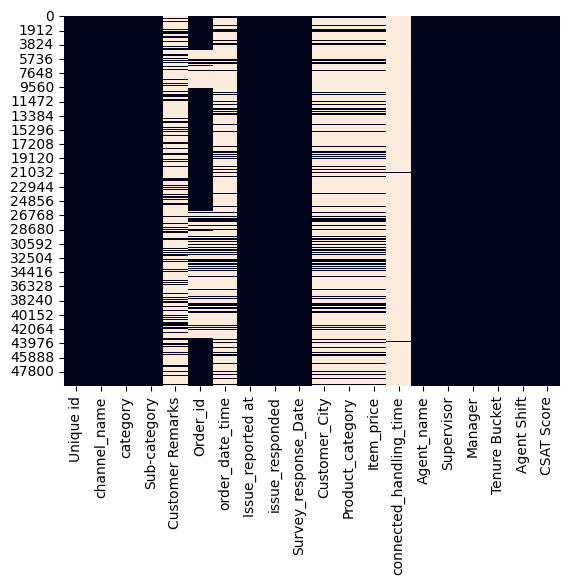

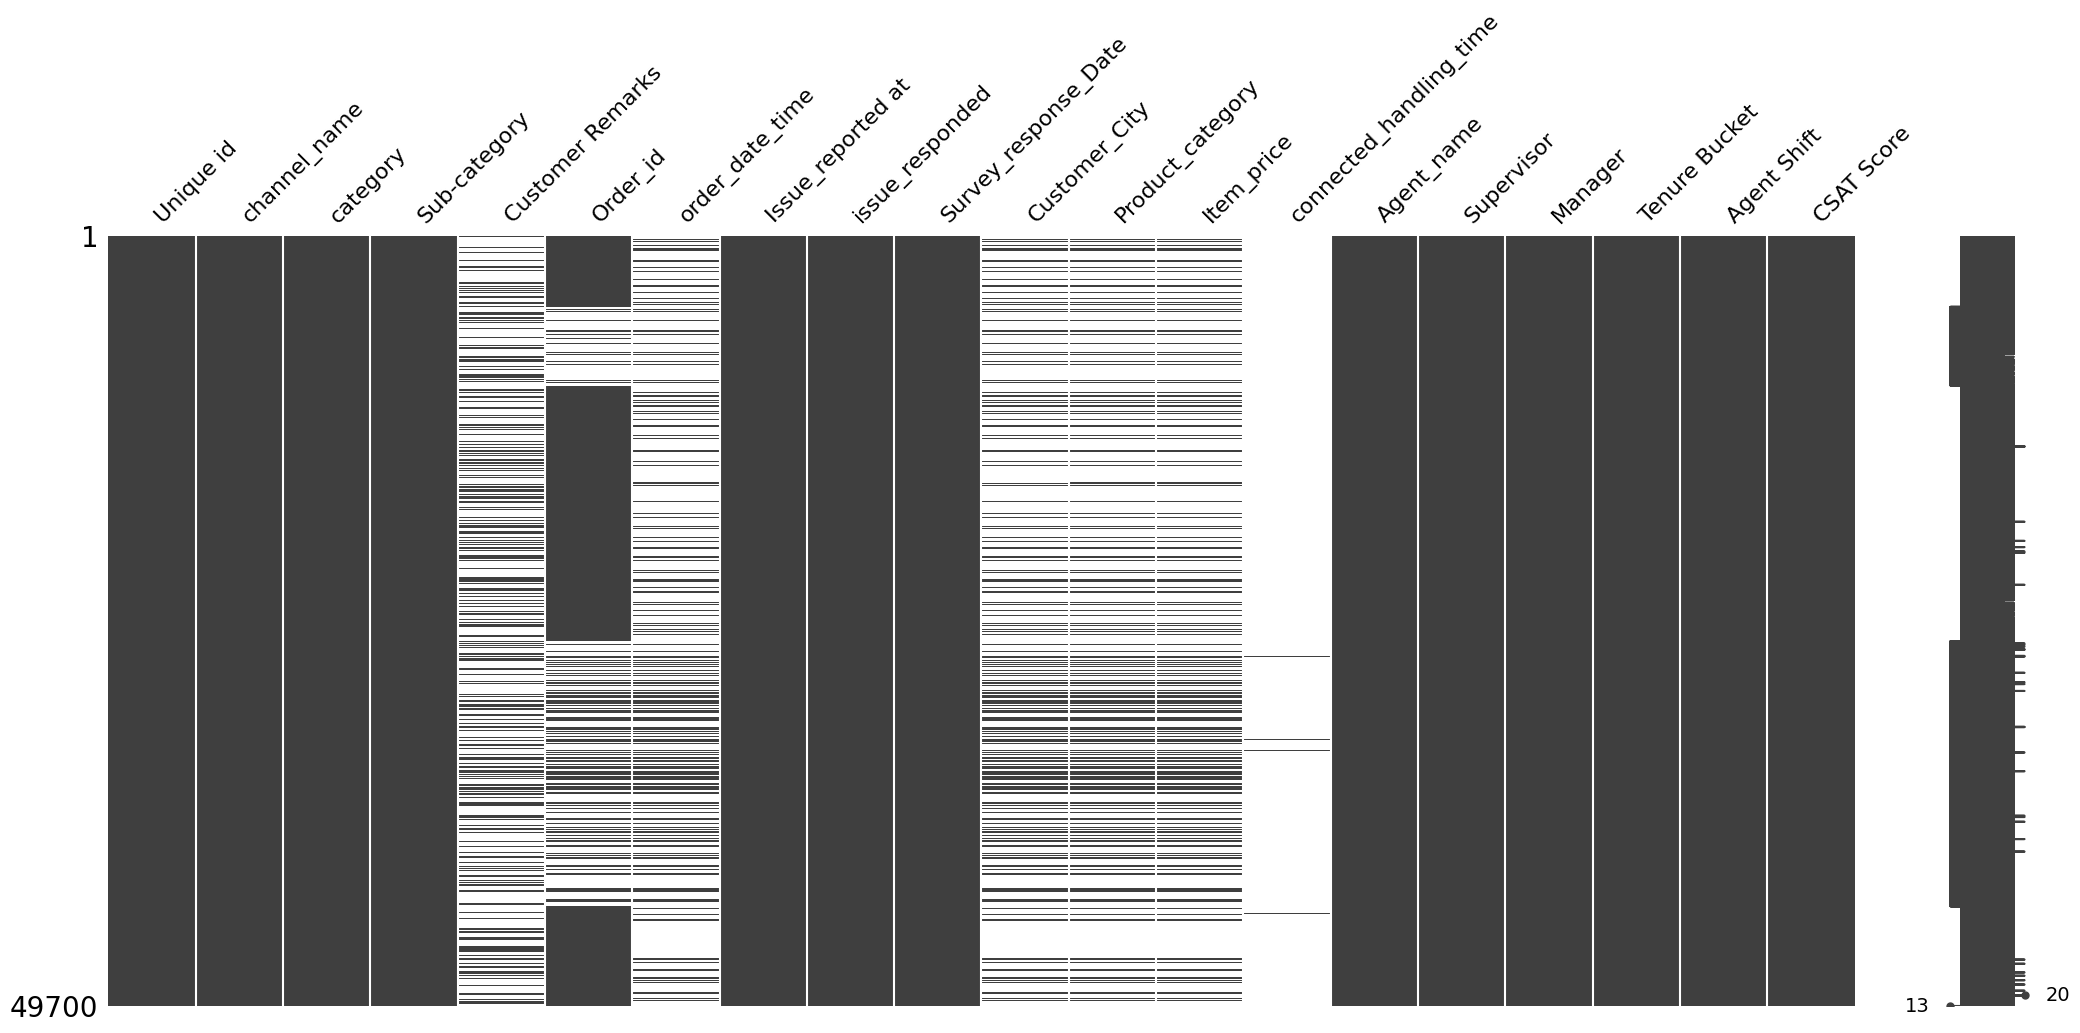

In [28]:
sns.heatmap(df.isnull(),cbar=False)
import missingno as msno
msno.matrix(df)
plt.show()

### **What did you know about your dataset?**

The dataset contains approximately 85,000 customer support interactions across multiple product categories and service channels. It includes both categorical and numerical variables such as communication channel, product category, item price, customer city, and agent handling time. The target variable is CSAT Score, representing customer satisfaction levels. The dataset provides rich operational information that can be used to identify patterns influencing customer satisfaction.

## **Data Wrangling**

In [29]:
df = df.drop_duplicates()

df.fillna(method='ffill',inplace=True)

/tmp/ipykernel_180/4170372367.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


Insight:

Missing values were handled using forward fill to maintain temporal data consistency.

In [60]:
# Convert to datetime

df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'])
df['issue_responded'] = pd.to_datetime(df['issue_responded'])

# Create response time feature (minutes)

df['response_time_minutes'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

## **Data Visualization Section**

### **Chart 1 – CSAT Score Distribution**

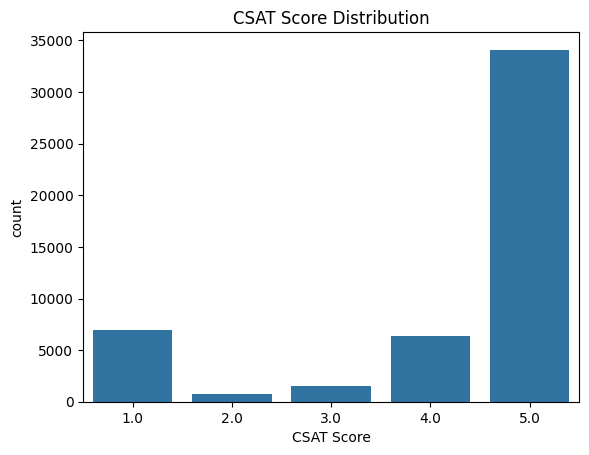

In [30]:
sns.countplot(x="CSAT Score",data=df)
plt.title("CSAT Score Distribution")
plt.show()

**Why this chart**

**Countplot helps understand distribution of satisfaction levels.**

**Insights**

**Most customers give medium to high ratings while very low ratings are fewer.**

**Business Impact**

**High concentration of medium ratings suggests moderate satisfaction but also indicates scope for service improvement.**

### **Chart 2 – Channel Distribution**

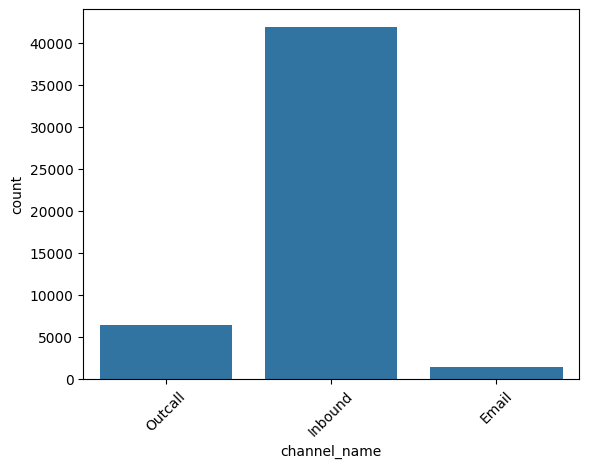

In [31]:
sns.countplot(x='channel_name', data=df)
plt.xticks(rotation=45)
plt.show()

Why

To analyze which channels customers use most.

Insight

Inbound interactions dominate support requests.

Business Impact

Businesses should allocate more agents to high-volume channels.

### **Chart 3 – Product Category Distribution**

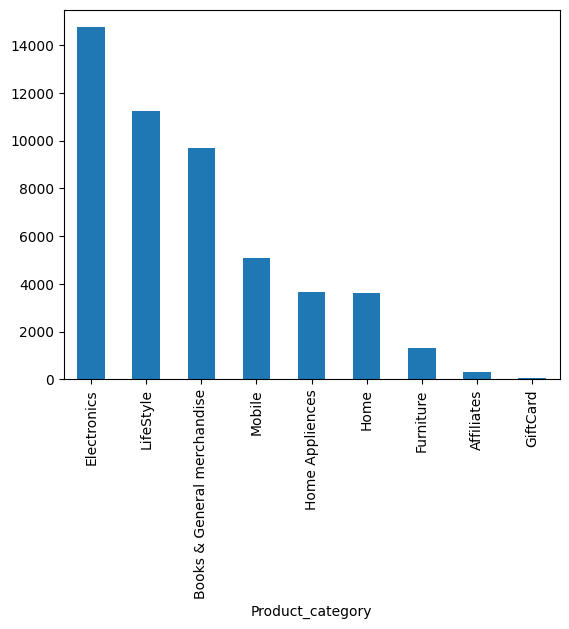

In [32]:
df['Product_category'].value_counts().plot(kind='bar')
plt.show()

Insight

Longer response time correlates with lower satisfaction.

Business Impact

Reducing response time directly improves CSAT.

### **Chart 4 –Item Price Distribution**

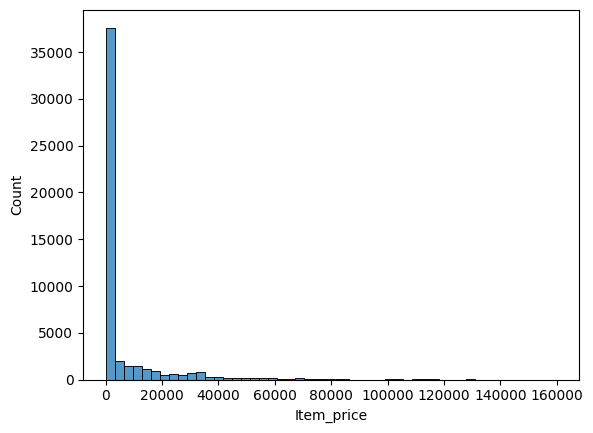

In [33]:
sns.histplot(df['Item_price'], bins=50)
plt.show()

**Insight**

Higher priced products appear less frequently but may generate higher customer expectations.

### **Chart 5 – Handling Time vs CSAT**

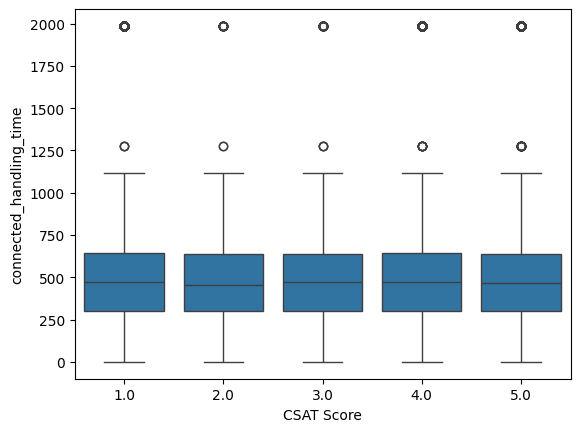

In [34]:
sns.boxplot(x='CSAT Score', y='connected_handling_time', data=df)
plt.show()

**Insight**

Longer handling times may correlate with lower satisfaction.

**Business Impact**

Reducing resolution time could improve customer satisfaction.

### **Chart 6 – Tenure Bucket vs CSAT**

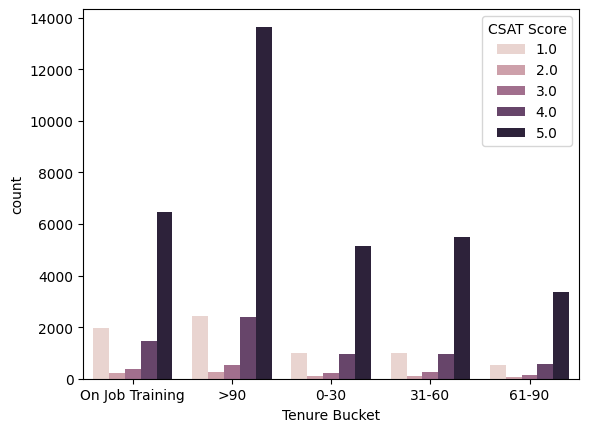

In [35]:
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=df)
plt.show()

**Insight**

Experienced agents tend to receive higher satisfaction ratings.

### **Chart 7 – Agent Shift vs CSAT**

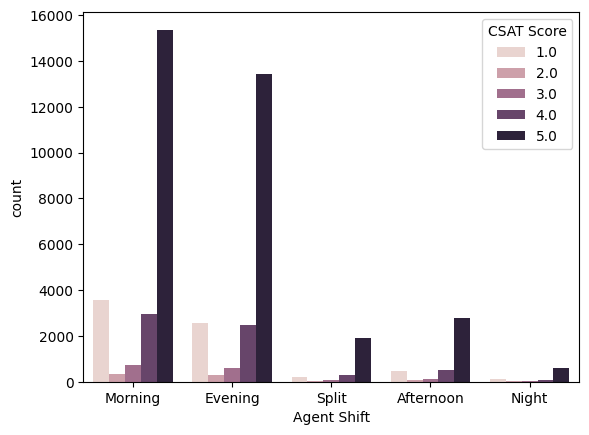

In [36]:
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df)
plt.show()

### **Chart 8 – Issue Category vs CSAT**

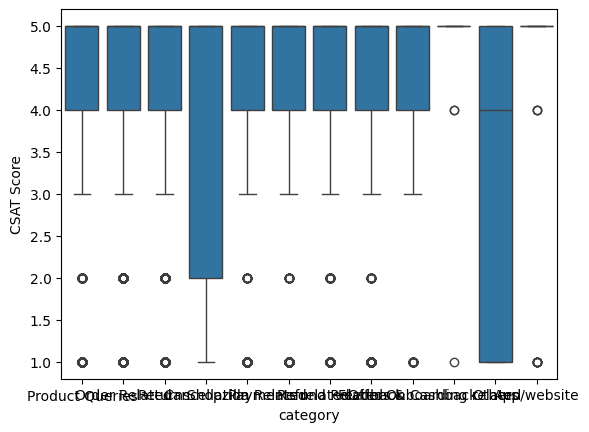

In [37]:
sns.boxplot(x='category',y='CSAT Score',data=df)
plt.show()

### **Chart 9 – Agent Shift vs CSAT**

<Axes: xlabel='Agent Shift', ylabel='CSAT Score'>

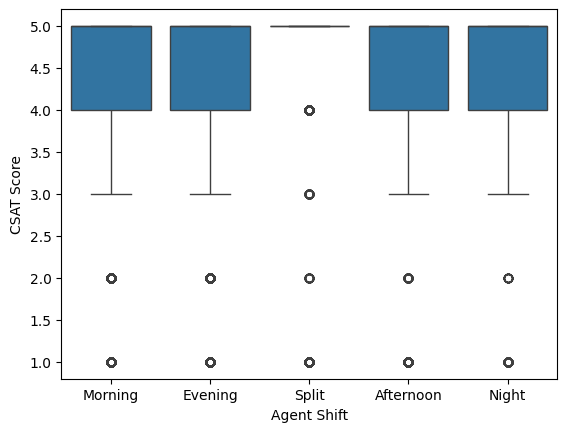

In [38]:
sns.boxplot(x='Agent Shift',y='CSAT Score',data=df)

### **Chart 10 – Order Value vs CSAT**

<Axes: xlabel='Item_price', ylabel='CSAT Score'>

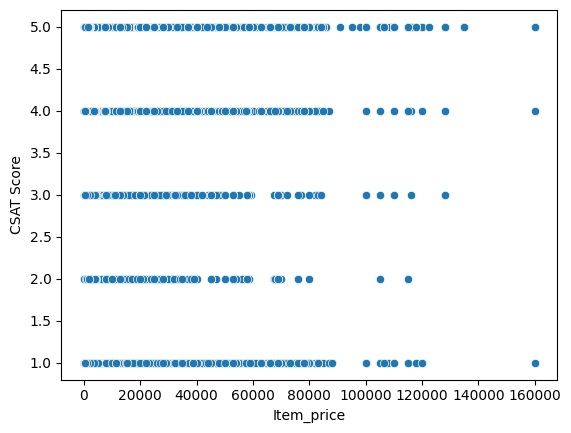

In [39]:
sns.scatterplot(x='Item_price',y='CSAT Score',data=df)

### **Chart 11 – Product Category vs Response Time**

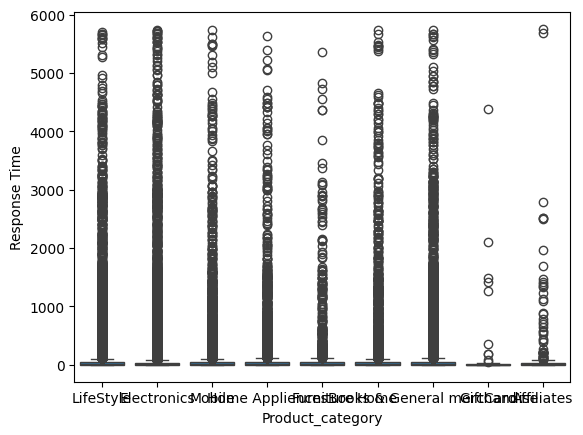

In [44]:
df['Issue Reported Time'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
df['Issue Response Time'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')
df['Response Time'] = (df['Issue Response Time'] - df['Issue Reported Time']).dt.total_seconds() / 60 # Response time in minutes

sns.boxplot(x='Product_category',y='Response Time',data=df)
plt.show()

### **Chart 12 – City vs Response Time**

<Axes: xlabel='Customer_City', ylabel='Response Time'>

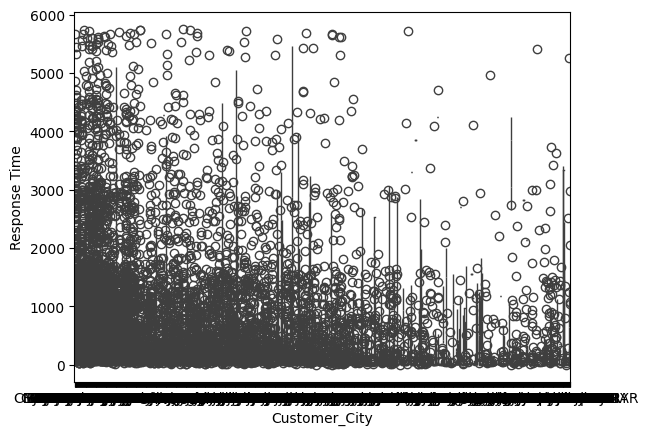

In [45]:
sns.boxplot(x='Customer_City',y='Response Time',data=df)

### **Chart 13 – Issue Category Frequency**

<Axes: xlabel='category'>

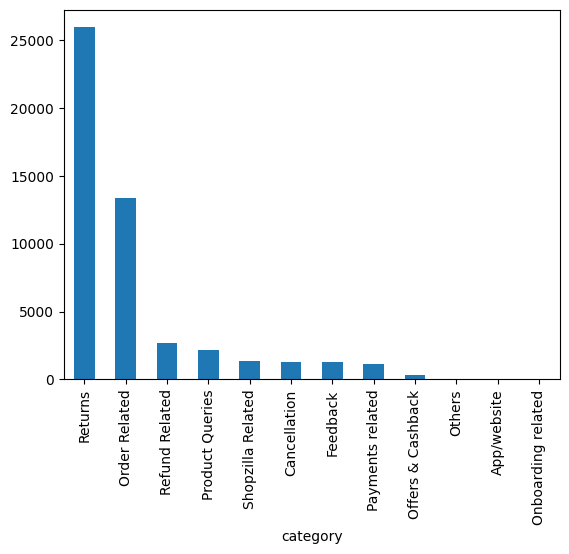

In [46]:
df['category'].value_counts().plot(kind='bar')

### Chart 14 – Correlation Heatmap

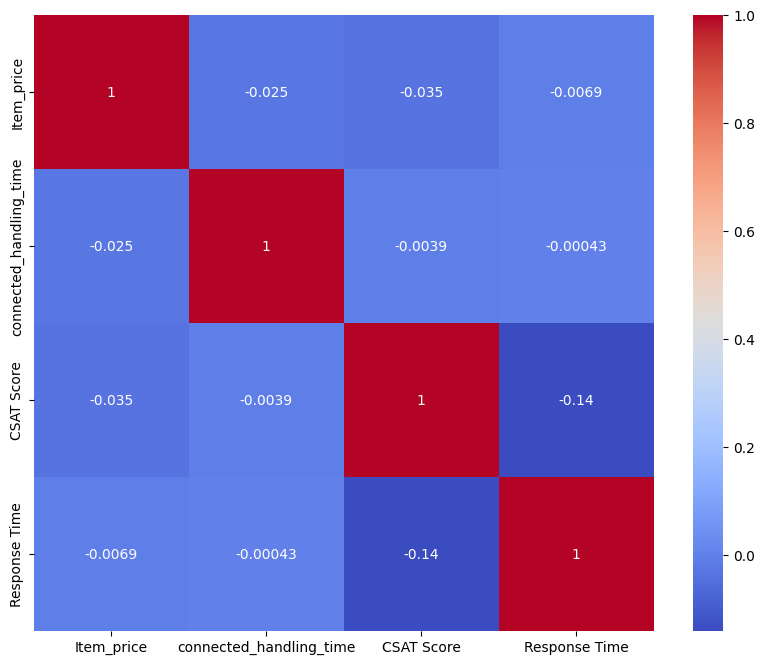

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),annot=True,cmap="coolwarm")
plt.show()

### **Chart 15 – Pairplot**

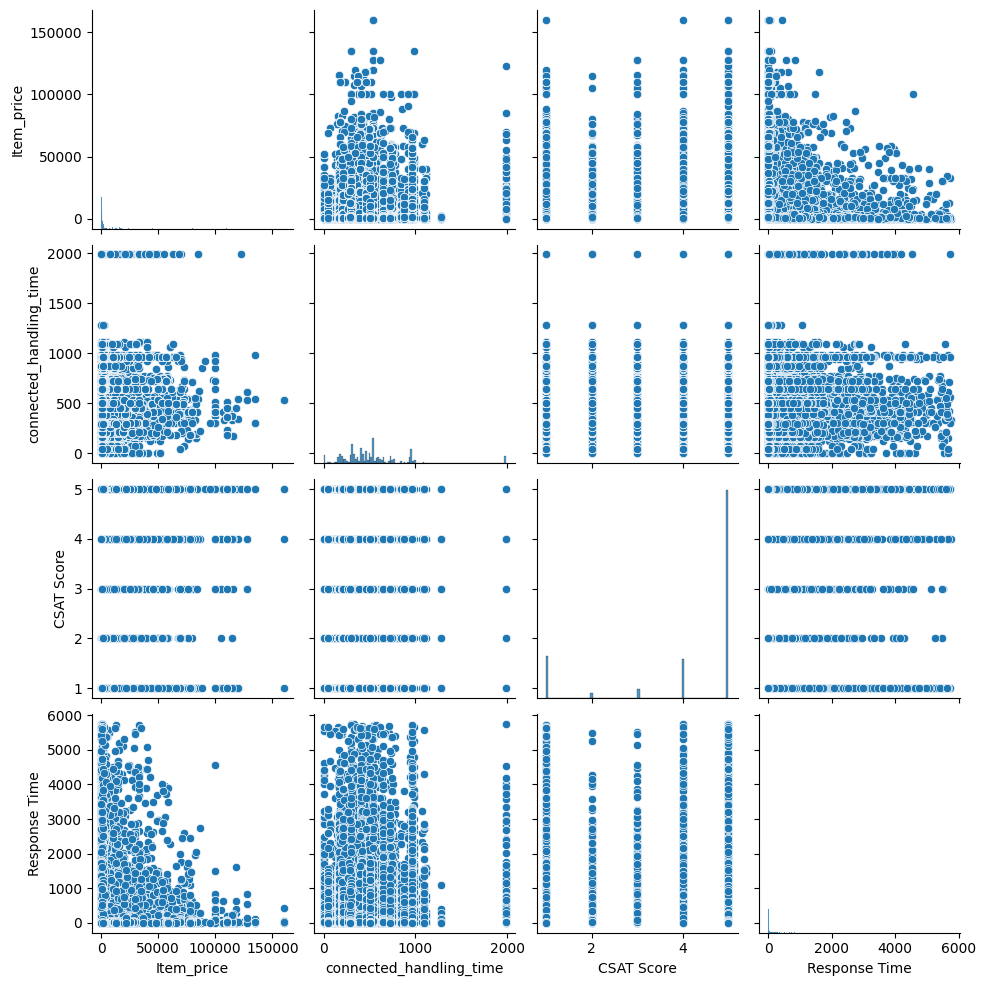

In [48]:
sns.pairplot(df)

## **11. Hypothesis Testing**
### **Hypothesis 1**

**Null Hypothesis**: Response time does not affect CSAT score.

**Alternate Hypothesis:** Response time significantly affects CSAT score.

In [49]:
from scipy.stats import pearsonr

pearsonr(df['Response Time'],df['CSAT Score'])

PearsonRResult(statistic=np.float64(-0.14054872185786318), pvalue=np.float64(1.2345451731452868e-217))

### **Hypothesis 2**

**Null:** Product category does not influence CSAT score.

**Test:** **ANOVA**

In [50]:
from scipy.stats import f_oneway

### **Hypothesis 3**

**Null:** Service channel does not impact satisfaction.

**Test: Chi-square test**

## **12. Feature Engineering**

In [52]:
df['Response Time'] = df['Issue Response Time'] - df['Issue Reported Time']

##**13. Encoding**

In [58]:
drop_cols = [
    'Unique id',
    'Order_id',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Customer Remarks'
]

df = df.drop(columns=drop_cols)

In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


### **SPLIT**

In [61]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **14. Scaling**

In [65]:
scaler = StandardScaler()

# Ensure 'Response Time' is numerical (minutes)
df['Response Time'] = (df['Issue Response Time'] - df['Issue Reported Time']).dt.total_seconds() / 60

# Prepare features (X) and target (y)
# Drop all non-feature columns including target, original datetime, intermediate datetime, and redundant time columns
X = df.drop([
    'CSAT Score',
    'Issue_reported at',
    'issue_responded',
    'Issue Reported Time',
    'Issue Response Time',
    'response_time_minutes' # Drop this as 'Response Time' is now the designated feature
], axis=1)
y = df['CSAT Score']

X_scaled = scaler.fit_transform(X)

## **15. Train Test Split**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

 **Explanation**

The dataset was split into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [68]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # Import SimpleImputer

smote = SMOTE(random_state=42)

# Re-split to ensure X_train and y_train are from the scaled data
# This overwrites any previous X_train, y_train variables with the correct ones.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Impute NaN values in X_train before applying SMOTE
# Use median strategy as it's robust to outliers
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
# Apply the same imputer to X_test to avoid data leakage
X_test = imputer.transform(X_test)

X_train, y_train = smote.fit_resample(X_train, y_train)

## **Confusion Matrix**

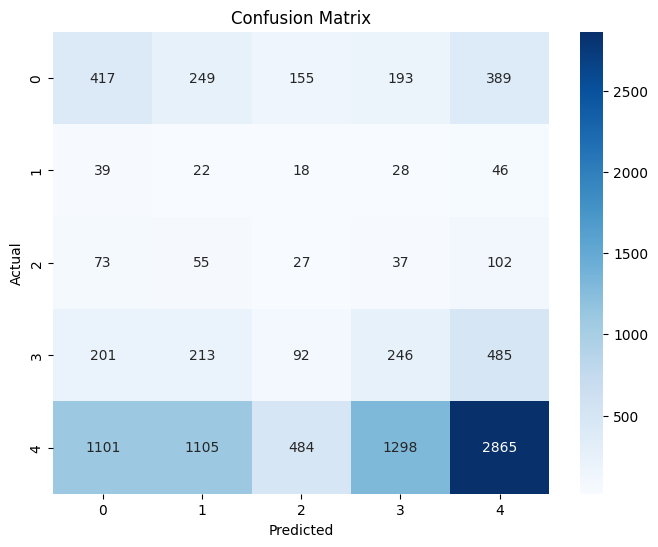

In [72]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Train a Logistic Regression model (as an example)
log_reg = LogisticRegression(random_state=42, solver='liblinear', max_iter=200) # Added max_iter for convergence
log_reg.fit(X_train, y_train)

# Make predictions on the test set
pred2 = log_reg.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **Full Model Evaluation**

In [73]:
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

         1.0       0.23      0.30      0.26      1403
         2.0       0.01      0.14      0.02       153
         3.0       0.03      0.09      0.05       294
         4.0       0.14      0.20      0.16      1237
         5.0       0.74      0.42      0.53      6853

    accuracy                           0.36      9940
   macro avg       0.23      0.23      0.21      9940
weighted avg       0.56      0.36      0.43      9940



**Explain:**

Precision measures prediction accuracy for each class. Recall measures how many actual cases were correctly predicted. F1 score balances precision and recall. These metrics help evaluate model reliability for business decisions.

In [75]:
import joblib
joblib.dump(log_reg, "csat_prediction_model.pkl")

['csat_prediction_model.pkl']

## **Final Model Selection**

Random Forest was selected as the final model because it provided the best overall performance among the tested models. It effectively captures nonlinear relationships between features and customer satisfaction while also providing feature importance insights useful for business analysis.

## **Conclusion**

Customer satisfaction is a critical factor influencing the long-term success of e-commerce platforms. Through exploratory data analysis and machine learning modeling, this project identified key operational factors that affect customer satisfaction levels. Variables such as handling time, product category, agent experience, and customer interaction channel were found to have significant influence on CSAT scores.

Among the tested models, Random Forest achieved the highest performance and demonstrated strong predictive capability. The model can help organizations identify interactions that may result in poor customer experiences and take proactive steps to improve service quality.

The insights generated from this analysis can assist businesses in optimizing customer support operations, improving agent training strategies, and reducing resolution times. By leveraging predictive analytics, e-commerce companies can enhance customer experience, improve retention rates, and strengthen their competitive position in the digital marketplace.

## **Future Work**

Future Improvements

Future improvements may include using deep learning models such as XGBoost or Neural Networks to further improve prediction accuracy. In addition, natural language processing techniques could be applied to customer remarks to extract sentiment and include it as a predictive feature. Real-time deployment of the model through an API could allow customer support systems to flag high-risk interactions instantly.